In [1]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
import operator
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [4]:
# define the structure schema for evalution and feed back


from pydantic import BaseModel, Field

class TweetEvaluate(BaseModel):

    evaluation: Literal['approved', 'need_imporvement'] = Field(..., description = "final evaluation")
    feedback: str = Field(..., description = "Feedback for tweet.")



In [7]:
structure_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluate)

In [9]:
# define the state:

class TweetPost(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'need_imporvement']
    feedback: str
    iteration: int
    max_iteration: int


    # maintain the history
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]



In [17]:
def generate_tweet(state: TweetPost):
    
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """)
    ]
    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}


In [24]:
def evaluate_tweet(state: TweetPost):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structure_evaluator_llm.invoke(messages)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}
    


In [19]:
def optimizer_tweet(state: TweetPost):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1


    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [20]:
# create function for route evaluation

def route_evaluation(state: TweetPost):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'need_improvement'


In [21]:
# define the State graph:

graph = StateGraph(TweetPost)

# add node
graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimizer', optimizer_tweet)

# add edge:

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'need_imporvement': 'optimizer'})
graph.add_edge('optimizer', 'evaluate')

# compile the graph:

workflow = graph.compile()

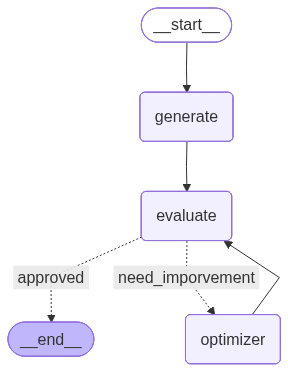

In [22]:
from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)

In [25]:
# execute the workflow

initial_state ={
    'topic': 'Indian Railway',
    'iteration': 1,
    'max_iteration': 3
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'Indian Railway', 'tweet': 'Indian Railways: where every journey is an episode of a soap opera. Dramatic entrances, surprise delays, and those unexpected plot twists—like finding out your ticket is confirmed but your seat is a standing room in the pantry. 🚂🍱✨', 'evaluation': 'approved', 'feedback': "This tweet is quite original, drawing an amusing parallel between the chaotic experiences on Indian Railways and the dramatics of a soap opera, which is fresh and relatable. The humor is clever and effective, likely to elicit smiles from readers who have experienced similar travel issues. It's punchy and engaging, utilizing vivid imagery to capture attention quickly. The potential for virality is high as many users could resonate with the content and may share it. Furthermore, it adheres to Twitter's format rules with a concise structure and fitting use of emojis.", 'iteration': 1, 'max_iteration': 3, 'tweet_history': ['Indian Railways: where every journey is an episode of a soap 